In [ ]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
X,y = make_regression(n_samples=100,n_features=1,noise=10,random_state=20)

In [ ]:
y=y.reshape(-1,1)

In [ ]:
y.shape

(100, 1)

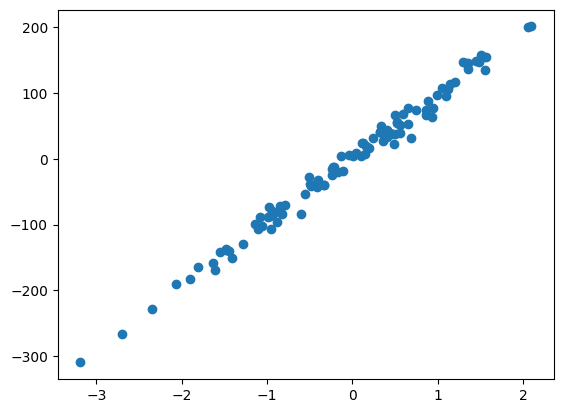

In [ ]:
plt.scatter(X,y)

# **Régression linéaire : implémentation de la descente de gradient from scratch**

In [ ]:
def model(X,a,b):
    return a*X + b

### Fonction de coût : Mean Squared Error (MSE)

$$
J(a,b)=\frac{1}{2n}\sum_{i=1}^{n}\left((a x_i + b) - y_i\right)^2
$$

In [ ]:
def cost_function(Yp,y):
    m=len(y)
    return 1/m * np.sum((y-Yp)**2)

Gradient de la fonction de coût

Le gradient correspond aux dérivées partielles de 𝐽(𝑎,𝑏) par rapport à chaque paramètre.

- Dérivée par rapport à 𝑎

$$
\frac{\partial J}{\partial a} = \frac{1}{n}\sum_{i=1}^{n} x_i \left((a x_i+b) - y_i\right)
$$

- Dérivée par rapport à 𝑏

$$
\frac{\partial J}{\partial b} = \frac{1}{n}\sum_{i=1}^{n} \left((a x_i+b) - y_i\right)
$$

In [ ]:
def gradient(X,y,a,b):
    m=len(y)
    y_predicted = model(X,a,b)
    gradienta = 1/m * np.sum((y_predicted-y)*X)
    gradientb = 1/m * np.sum(y_predicted-y)
    return (gradienta,gradientb)

### Mise à jour des paramètres (Descente de gradient)

$$
a^{(n+1)} = a^{(n)} - \alpha \frac{\partial J}{\partial a}
$$

$$
b^{(n+1)} = b^{(n)} - \alpha \frac{\partial J}{\partial b}
$$

### Condition de convergence

Lorsque les dérivées partielles tendent vers zéro :

$$
\frac{\partial J}{\partial a} \rightarrow 0
\quad \text{et} \quad
\frac{\partial J}{\partial b} \rightarrow 0
$$

alors :

$$
a^{(n+1)} \approx a^{(n)}
\quad \text{et} \quad
b^{(n+1)} \approx b^{(n)}
$$

Le modèle **cesse donc de se modifier** et les paramètres convergent vers
le **minimum de la fonction de coût**.

In [ ]:
def update(a,b,da,db,learning_rate):
    a = a - learning_rate * da
    b = b - learning_rate * db
    return(a,b)

In [ ]:
def descente_gradient(X,y,a = 0 ,b = 0 ,n_iteration = 1000,learning_rate = 0.01):
    cost_history = []
    for i in range(1,n_iteration):
        y_predicted = model(X,a,b)
        cost = cost_function(y_predicted,y)
        cost_history.append(cost)
        gradienta,gradientb= gradient(X,y,a,b)
        (a,b) = update(a,b,gradienta,gradientb,learning_rate)
    return (a,b,cost_history)

In [ ]:
final_a,final_b, cost_history = descente_gradient(X,y)

### Évolution de la fonction de coût

La courbe suivante représente l’évolution de la fonction de coût $J$ au cours des itérations de la descente de gradient.

Chaque point correspond à la valeur de l’erreur calculée après une mise à jour des paramètres du modèle.

Si l’algorithme fonctionne correctement, la fonction de coût diminue progressivement puis se stabilise.  
Cela signifie que les paramètres du modèle convergent vers les valeurs qui minimisent l’erreur.

Text(0, 0.5, 'Fonction Coût J(a)')

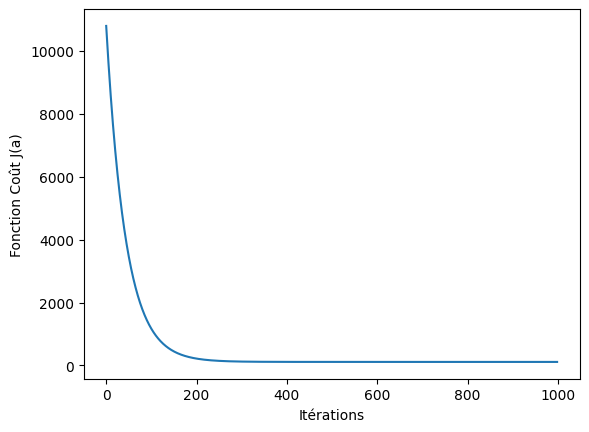

In [ ]:
plt.plot(cost_history)
plt.xlabel("Itérations")
plt.ylabel("Fonction Coût J(a)")

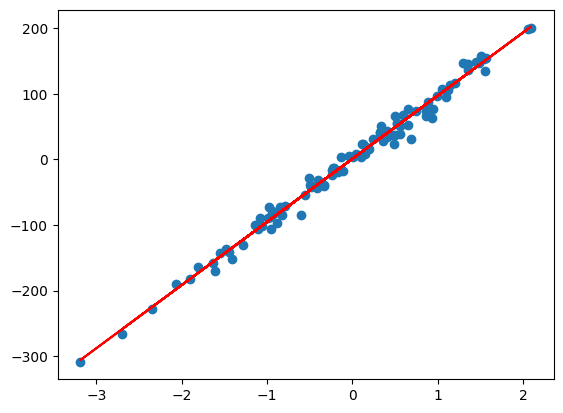

In [ ]:
plt.scatter(X,y)
plt.plot(X,model(X,final_a,final_b),color="red")

In [ ]:
final_a

np.float64(96.25150560914058)

Ici, on trace la fonction de coût en fonction du paramètre a. On remarque que la tangente au point optimal est horizontale, ce qui signifie que la dérivée au point minimum est nulle :

f′(a)=0.

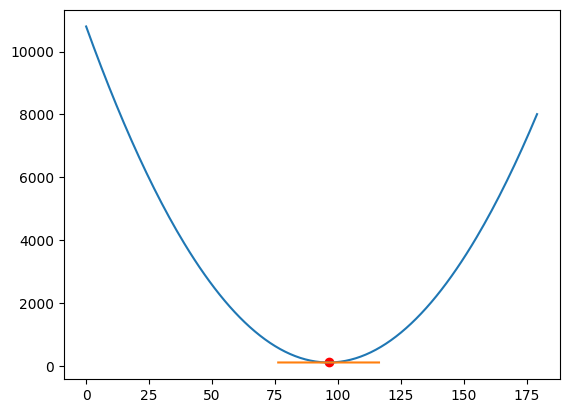

In [ ]:

# Calcul des coûts pour différentes valeurs de a
a_values = np.arange(180)
cout_values = [cost_function(model(X,a,final_b),y) for a in a_values]

# Calcul de la tangente au point a
y_pred = model(X, final_a, final_b)
x_tangeante = [final_a - 20 , final_a + 20]
y_tangeante = [gradient(X,y,final_a,final_b) [0] * (a-final_a) + cost_function(y_pred,y) for a in x_tangeante]

# Affichage
plt.plot(final_a,cost_function(y_pred,y),'ro')
plt.plot(cout_values)
plt.plot(x_tangeante,y_tangeante)

# **Régression linéaire : implémentation avec scikit-learn**

In [ ]:
from sklearn.linear_model import SGDRegressor

In [ ]:
regressor = SGDRegressor()

In [ ]:
regressor.fit(X,y)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SGDRegressor()

Prédiction d'une valeur

In [ ]:
print(regressor.predict([[12]]))

[1155.90351697]


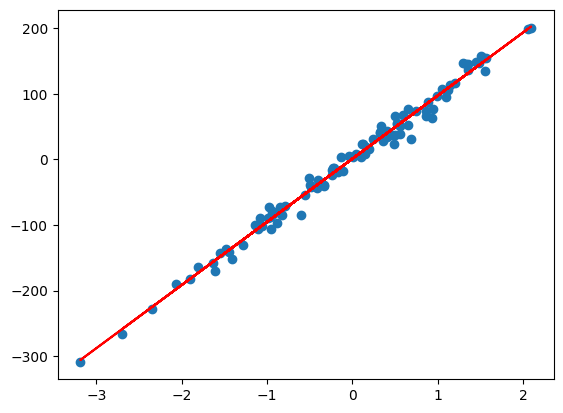

In [ ]:
plt.scatter(X,y)
plt.plot(X,regressor.predict(X),color='red')